In [2]:
import random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt
import imageio
from IPython.display import Image, display

In [3]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device('cuda')

In [4]:
DATA_DIR = Path('data/stl10')

img_size = 32
batch_size = 128
num_workers = 2

transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.CenterCrop(img_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

dataset = datasets.STL10(root=str(DATA_DIR), split='train+unlabeled', download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)

print('samples:', len(dataset))

100%|██████████| 2.64G/2.64G [03:04<00:00, 14.3MB/s] 


samples: 105000


In [5]:
nz = 128
ngf = 96
ndf = 64
nc = 3

class Generator(nn.Module):
    def __init__(self, nz, ngf, nc):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.main(x)

class Discriminator(nn.Module):
    def __init__(self, ndf, nc):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.main(x).view(-1)

def weights_init(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

netG = Generator(nz, ngf, nc).to(device)
netD = Discriminator(ndf, nc).to(device)
netG.apply(weights_init)
netD.apply(weights_init)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
  )
)

In [6]:
lr = 1e-4
beta1 = 0.5
num_epochs = 50

criterion = nn.BCEWithLogitsLoss()
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

writer = SummaryWriter(log_dir='logs')
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

output_dir = Path('outputs')
output_dir.mkdir(exist_ok=True)

global_step = 0
for epoch in range(num_epochs):
    lossD_epoch = []
    lossG_epoch = []

    for real, _ in dataloader:
        real = real.to(device)
        b_size = real.size(0)

        netD.zero_grad()
        labels_real = torch.ones(b_size, device=device)
        output_real = netD(real)
        lossD_real = criterion(output_real, labels_real)

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        labels_fake = torch.zeros(b_size, device=device)
        output_fake = netD(fake.detach())
        lossD_fake = criterion(output_fake, labels_fake)

        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()

        netG.zero_grad()
        output_fake_for_g = netD(fake)
        lossG = criterion(output_fake_for_g, labels_real)
        lossG.backward()
        optimizerG.step()

        lossD_epoch.append(lossD.item())
        lossG_epoch.append(lossG.item())

        writer.add_scalar('loss/D', lossD.item(), global_step)
        writer.add_scalar('loss/G', lossG.item(), global_step)
        global_step += 1

    mean_lossD = float(np.mean(lossD_epoch))
    mean_lossG = float(np.mean(lossG_epoch))
    print(f'Epoch {epoch+1}/{num_epochs} | LossD {mean_lossD:.4f} | LossG {mean_lossG:.4f}')

    with torch.no_grad():
        fake = netG(fixed_noise)
    utils.save_image(fake, output_dir / f'epoch_{epoch+1:03d}.png', nrow=8, normalize=True, value_range=(-1, 1))
    writer.add_images('samples', (fake * 0.5 + 0.5).clamp(0, 1), epoch)

Epoch 1/50 | LossD 0.3773 | LossG 3.8390
Epoch 2/50 | LossD 0.3388 | LossG 3.6765
Epoch 3/50 | LossD 0.4131 | LossG 3.0381
Epoch 4/50 | LossD 0.5060 | LossG 2.6500
Epoch 5/50 | LossD 0.6062 | LossG 2.3985
Epoch 6/50 | LossD 0.6392 | LossG 2.2586
Epoch 7/50 | LossD 0.6320 | LossG 2.2130
Epoch 8/50 | LossD 0.6120 | LossG 2.2579
Epoch 9/50 | LossD 0.5676 | LossG 2.3262
Epoch 10/50 | LossD 0.5933 | LossG 2.3626
Epoch 11/50 | LossD 0.6307 | LossG 2.2156
Epoch 12/50 | LossD 0.6277 | LossG 2.1614
Epoch 13/50 | LossD 0.6521 | LossG 2.1451
Epoch 14/50 | LossD 0.6508 | LossG 2.1282
Epoch 15/50 | LossD 0.6899 | LossG 2.0708
Epoch 16/50 | LossD 0.6985 | LossG 2.0338
Epoch 17/50 | LossD 0.7284 | LossG 1.9871
Epoch 18/50 | LossD 0.7359 | LossG 1.9645
Epoch 19/50 | LossD 0.7694 | LossG 1.9438
Epoch 20/50 | LossD 0.7547 | LossG 1.9406
Epoch 21/50 | LossD 0.7557 | LossG 1.9201
Epoch 22/50 | LossD 0.7260 | LossG 1.9249
Epoch 23/50 | LossD 0.7721 | LossG 1.9199
Epoch 24/50 | LossD 0.7621 | LossG 1.9212
E

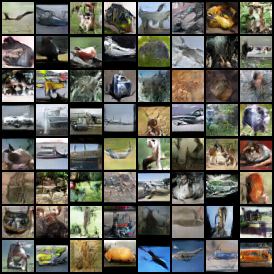

In [7]:
from PIL import Image as PILImage
last_grid = sorted(Path('outputs').glob('epoch_*.png'))[-1]
display(PILImage.open(last_grid))


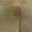

In [8]:
def latent_inversion(target_img, steps=400, lr=0.05):
    netG.eval()
    z = torch.randn(1, nz, 1, 1, device=device, requires_grad=True)
    optimizer = optim.Adam([z], lr=lr)
    loss_fn = nn.MSELoss()

    for _ in range(steps):
        optimizer.zero_grad()
        gen = netG(z)
        loss = loss_fn(gen, target_img)
        loss.backward()
        optimizer.step()

    return z.detach()

real_A, _ = dataset[0]
real_B, _ = dataset[1]
real_A = real_A.unsqueeze(0).to(device)
real_B = real_B.unsqueeze(0).to(device)

zA = latent_inversion(real_A)
zB = latent_inversion(real_B)

steps = 30
alphas = torch.linspace(0, 1, steps).to(device)
frames = []

with torch.no_grad():
    for a in alphas:
        z = (1 - a) * zA + a * zB
        img = netG(z).squeeze(0)
        img = (img * 0.5 + 0.5).clamp(0, 1)
        img_np = (img.permute(1, 2, 0).cpu().numpy() * 255).astype('uint8')
        frames.append(img_np)

gif_path = output_dir / 'latent_interp.gif'
imageio.mimsave(gif_path, frames, duration=0.08)

display(Image(filename=str(gif_path)))

In [ ]:
# изображения и гиф в папке outputs